# <span style="color:#2E86C1;">GMM-Based Anomaly Detection Using the EM Algorithm</span>

The **<span style="color:#2E86C1;">GMM</span>** learns the distribution of **<span style="color:#27AE60;">normal data</span>** by estimating the **<span style="color:#E67E22;">means (μ)</span>**, **<span style="color:#E67E22;">covariances (Σ)</span>**, and **<span style="color:#E67E22;">mixing weights (π)</span>** using the **<span style="color:#8E44AD;">EM algorithm</span>**. After training, it calculates a **<span style="color:#16A085;">probability score</span>** for each data point. Points with very **<span style="color:#E74C3C;">low probability</span>** are considered **<span style="color:#E74C3C;">anomalies</span>**.

In [ ]:
import numpy as np

# GMM Class
class GMM:
    def __init__(self, n_components=2, max_iter=100, tol=1e-4):
        self.n_components = n_components
        self.max_iter = max_iter
        self.tol = tol
        self.means = None
        self.covariances = None
        self.weights = None

    # Gaussian Probability Density Function
    def gaussian_pdf(self, X, mean, covariance):
        n_features = X.shape[1]

        # Prevent singular covariance matrix
        covariance = ( covariance + 1e-6 * np.eye(n_features) )
        det = np.linalg.det(covariance)
        inv = np.linalg.inv(covariance)
        diff = X - mean
        exponent = -0.5 * np.sum( (diff @ inv) * diff, axis=1 )
        denominator = np.sqrt( ((2 * np.pi) ** n_features) * det )
        return np.exp(exponent) / denominator

    # Initialization
    def initialize(self, X):
        n_samples, n_features = X.shape

        # Randomly select initial means
        random_indices = np.random.choice(
            n_samples,
            self.n_components,
            replace=False )
        self.means = X[random_indices].copy()

        # Initial covariance
        global_cov = np.cov(X.T)

        if n_features == 1:
            global_cov = np.array([[global_cov]])

        self.covariances = np.array([
            global_cov.copy()
            for _ in range(self.n_components)])

        # Initial mixing weights
        self.weights = ( np.ones(self.n_components) / self.n_components )

    # E-Step
    def e_step(self, X):
        n_samples = X.shape[0]
        responsibilities = np.zeros( (n_samples, self.n_components) )
        for k in range(self.n_components):
            probability = self.gaussian_pdf( X,
                self.means[k],
                self.covariances[k]  )

            responsibilities[:, k] = ( self.weights[k] * probability  )

        # Sum probability of all Gaussians
        total_probability = np.sum(
            responsibilities, axis=1, keepdims=True)

        # Normalize probabilities
        responsibilities /= (
            total_probability + 1e-12 )
        return responsibilities

    # M-Step
    def m_step(self, X, responsibilities):
        n_samples, n_features = X.shape
        
        # Number of points assigned to each Gaussian
        N_k = np.sum( responsibilities, axis=0 )

        # Update Mixing Weights 
        self.weights = ( N_k / n_samples )

        # Update Means μ
        self.means = np.zeros((
                self.n_components, n_features))
        for k in range(self.n_components):
            self.means[k] = (np.sum(
                    responsibilities[:, k, None]
                    * X, axis=0)/(N_k[k] + 1e-12))

        # Update Covariance Σ
        self.covariances = np.zeros( (
                self.n_components,n_features,n_features  ) )
        for k in range(self.n_components):
            diff = ( X - self.means[k] )
            weighted_diff = ( responsibilities[:, k, None]* diff )
            covariance = ( weighted_diff.T @ diff / (N_k[k] + 1e-12) )

            # Regularization
            covariance += (1e-6 * np.eye(n_features) )
            self.covariances[k] = covariance

    # EM Training
    def fit(self, X):
        self.initialize(X)
        for _ in range(self.max_iter):
            responsibilities = self.e_step(X)
            self.m_step(X, responsibilities  )

    # Probability Score
    def score_samples(self, X):
        probabilities = np.zeros(X.shape[0] )
        for k in range(
            self.n_components):
            gaussian_probability = (
                self.gaussian_pdf(X,
                    self.means[k],
                    self.covariances[k] ))

            probabilities += (
                self.weights[k]
                * gaussian_probability )

        return np.log(probabilities+ 1e-12)

# Generate Data
np.random.seed(42)

# Normal Cluster 1
cluster1 = np.random.multivariate_normal(
    mean=[0, 0],
    cov=[
        [1, 0.3],
        [0.3, 1] ] ,size=100)

# Normal Cluster 2
cluster2 = np.random.multivariate_normal(
    mean=[5, 5],
    cov=[
        [1, -0.2],
        [-0.2, 1] ],size=100)

# Combine Normal Data
X_normal = np.vstack([
    cluster1,
    cluster2])

# Anomalies
X_anomalies = np.array([
    [10, 10],
    [-8, -7],
    [10, -5],
    [-6, 8]])

# Training Data
X = X_normal

# Create GMM
gmm = GMM(
    n_components=2,
    max_iter=100,
    tol=1e-4)

# Train GMM
gmm.fit(X)

# Display Learned Parameters
print("====================================")
print("GMM Parameters")
print("====================================")
print("\nMeans (μ):")
print(gmm.means)
print("\nMixing Weights (π):")
print(gmm.weights)
print("\nCovariances (Σ):")
print(gmm.covariances)

# Calculate Scores
normal_scores = gmm.score_samples( X_normal)
anomaly_scores = gmm.score_samples(X_anomalies)

# Display Scores
print("\n====================================")
print("Normal Data Scores")
print("====================================")
print(normal_scores[:10])
print("\n====================================")
print("Anomaly Scores")
print("====================================")
print(anomaly_scores)

GMM Parameters

Means (μ):
[[0.07303615 0.11328779]
 [4.92814833 5.12683382]]

Mixing Weights (π):
[0.49999779 0.50000221]

Covariances (Σ):
[[[ 0.84367341  0.12613491]
  [ 0.12613491  0.79143849]]

 [[ 1.06683599 -0.29587986]
  [-0.29587986  0.90921959]]]

Normal Data Scores
[-2.59457364 -3.79875273 -2.36194631 -4.52250383 -2.54132092 -2.52037312
 -4.35328483 -4.24638336 -2.92155499 -3.76623938]

Anomaly Scores
[-27.63099927 -27.63102112 -27.63102112 -27.63102112]


# <span style="color:#2E86C1;">GMM Anomaly Detection Visualization</span>

The plot shows the **<span style="color:#27AE60;">normal data</span>**, **<span style="color:#E74C3C;">anomalies</span>**, and the **<span style="color:#8E44AD;">GMM means</span>**. Normal data points are displayed as **dots**, anomalies as **X markers**, and the GMM centers as **stars**. This visualization helps us clearly see how the **<span style="color:#E67E22;">anomalies</span>** are located far from the normal clusters.

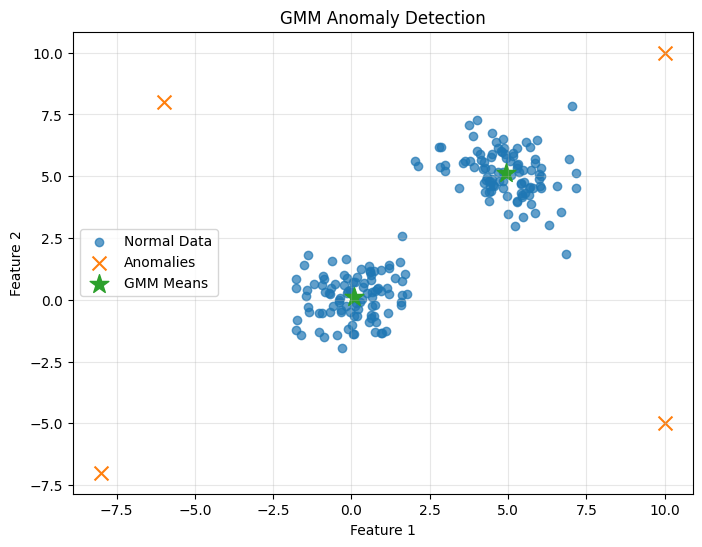

In [10]:
import matplotlib.pyplot as plt

# Plot Normal Data and Anomalies
plt.figure(figsize=(8, 6))

# Normal data
plt.scatter(
    X_normal[:, 0],
    X_normal[:, 1],
    label="Normal Data",
    alpha=0.7)

# Anomalies
plt.scatter(
    X_anomalies[:, 0],
    X_anomalies[:, 1],
    label="Anomalies",
    marker="x",
    s=100)

# GMM Means
plt.scatter(
    gmm.means[:, 0],
    gmm.means[:, 1],
    marker="*",
    s=200,
    label="GMM Means")

plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.title("GMM Anomaly Detection")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()